In [1]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA
from sklearn.svm import LinearSVC
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from utils import age_regression, sex_classification

In [2]:
res_dir = "/data/users4/xli/MSIVA/MSIVA/results"
A = sio.loadmat(os.path.join(res_dir, "mat", "A_ukb.mat"))["A"]
A_msiva_s2_shared = A[1,1,:,:,:10]
A_msiva_s2 = A[1,1,:,:,:]

data = sio.loadmat(os.path.join(res_dir, "img", "s2", "ummm_neuroimaging_Y.mat"))
Y_msiva_s2 = np.squeeze(data['Y2'])

Y_msiva_s2_shared_cca = sio.loadmat(os.path.join(res_dir, "img", "s2", "Y_msiva_s2_cca.mat"))["Y_msiva_s2_cca"]
unique_source = np.concatenate( [np.expand_dims( Y_msiva_s2[0][-2:,:], axis=0 ), np.expand_dims( Y_msiva_s2[1][-2:,:], axis=0 )], axis=0 )
Y_msiva_s2_cca = np.concatenate( [Y_msiva_s2_shared_cca, unique_source], axis=1 )

data = sio.loadmat(os.path.join(res_dir, "img", "s5", "mm_neuroimaging_Y.mat"))
Y_mmiva_s5 = np.squeeze(data['Y3'])

In [3]:
ukb_smri_data_path = os.path.join(res_dir, "mat", "UKB_MMIVA_C30_preregSite_SMRI_MancovanOuts_wX_FINAL.mat")
ukb_smri_data = sio.loadmat(ukb_smri_data_path)['MODELUKB0s_ful']
ukb_smri_data_array = ukb_smri_data[0][0][0]
ukb_smri_data_key = np.squeeze(ukb_smri_data[0][0][3])
age_idx = np.where(ukb_smri_data_key==['age_when_attended_assessment_centre_f21003_2_0'])[0][0]
sex_idx = np.where(ukb_smri_data_key==['sex_f31_0_0'])[0][0]
age = ukb_smri_data_array[:, age_idx]
sex = ukb_smri_data_array[:, sex_idx]

In [4]:
r_sq = np.zeros((2, 5, 12))
r_sq_adj = np.zeros((2, 5, 12))

for m in range(2):
    for i, j in enumerate(np.arange(0,10,2)):
        for k in range(12):
            msiva_s2 = Y_msiva_s2_cca[m,j:j+2,:].T
            mmiva_s5 = Y_mmiva_s5[m][k,:]
            results = sm.OLS(mmiva_s5, msiva_s2).fit()
            r_sq[m, i, k] = results.rsquared
            r_sq_adj[m, i, k] = results.rsquared_adj

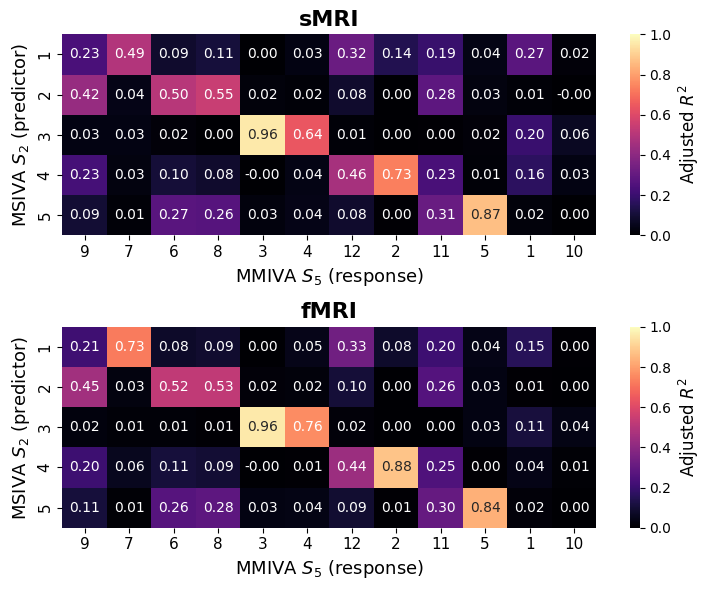

In [5]:
# ind = [7,9,8,6,3,4,2,12,5,11,1,10]
ind = [9,7,6,8,3,4,12,2,11,5,1,10]
ind0 = [ i - 1 for i in ind ]
title_list = ["sMRI", "fMRI"]

plt.figure(figsize=(7.5,6))

for i in range(2):
    plt.subplot(2,1,i+1)
    f = sns.heatmap(r_sq_adj[i][:,ind0], vmin=0, vmax=1, cmap="magma", annot=True, fmt=".2f")
    # sns.heatmap(r_sq[i], vmin=0, vmax=1, cmap="magma", annot=True, fmt=".2f")
    cb = f.collections[0].colorbar
    cb.ax.tick_params(labelsize=10)
    cb.set_label(label=f"Adjusted $R^2$", fontsize=12)
    plt.title(f"{title_list[i]}", fontsize=16, fontweight="bold")
    plt.xlabel("MMIVA $S_5$ (response)", fontsize=13)
    plt.ylabel("MSIVA $S_2$ (predictor)", fontsize=13)
    plt.xticks(np.arange(0.5,12.5,1), np.arange(1,13)[ind0], fontsize=11)
    plt.yticks(np.arange(0.5,5.5,1), np.arange(1,6), fontsize=11)

plt.tight_layout()
plt.savefig("figures/Rsq_MMIVA_S5_vs_MSIVA_S2_reordered_CCA_UKB.pdf")

In [6]:
Y_mmiva_s5_sorted = [Y_mmiva_s5[0][ind0], Y_mmiva_s5[1][ind0]]

regularizer_range = np.linspace(0.1, 1, 10)
param_grid_rr = [{'alpha': regularizer_range}]
param_grid_svm = [{'C': regularizer_range}]

age_mae = np.zeros(5)
age_coef = np.zeros((5, 4))
sex_acc = np.zeros(5)
sex_coef = np.zeros((5, 4))

for i in range(5):
    X12 = (np.concatenate((Y_mmiva_s5_sorted[0][2*i:2*i+2], Y_mmiva_s5_sorted[1][2*i:2*i+2]), axis=0)).T # S1M1, S2M1, S1M2, S2M2

    X_train, X_test, y_train, y_test = train_test_split(X12, age, test_size=0.312, random_state=42, stratify=age)
    base_estimator = Ridge()
    rr = GridSearchCV(base_estimator, param_grid_rr, cv=10).fit(X_train, y_train)
    mae, coef = age_regression(X_train, X_test, y_train, y_test, a=rr.best_params_['alpha'])
    age_mae[i] = mae
    age_coef[i] = coef

    X_train, X_test, y_train, y_test = train_test_split(X12, sex, test_size=0.312, random_state=42, stratify=sex)
    base_estimator = LinearSVC(dual=False)
    svc = GridSearchCV(base_estimator, param_grid_svm, cv=10).fit(X_train, y_train)
    acc, coef = sex_classification(X_train, X_test, y_train, y_test, c=svc.best_params_['C'])
    sex_acc[i] = acc*100
    sex_coef[i] = coef[0]

    print(f"Subspace {i+1}: age regression MAE {mae:.3f}; sex classification accuracy {acc*100:.3f}")

Subspace 1: age regression MAE 6.020; sex classification accuracy 58.874
Subspace 2: age regression MAE 5.541; sex classification accuracy 63.729
Subspace 3: age regression MAE 6.100; sex classification accuracy 66.483
Subspace 4: age regression MAE 6.054; sex classification accuracy 60.085
Subspace 5: age regression MAE 5.470; sex classification accuracy 75.415


In [7]:
f_stats = np.zeros( (4, 2, 5, 6) )
p_vals = np.zeros( (4, 2, 5, 6) )

for m in range(2):
    for a, i in enumerate(np.arange(0,10,2)):
        for b, j in enumerate(np.arange(0,12,2)):
            y = Y_msiva_s2_cca[m,i:i+2,:].T
            X = Y_mmiva_s5[m][ind0][j:j+2,:].T

            data = np.concatenate((X, y), axis=1)
            data_name = ['S5SCV1', 'S5SCV2', 'S2SCV1', 'S2SCV2']
            df = pd.DataFrame(data, columns=data_name)
            df.head(5)

            # response ~ predictor
            model = MANOVA.from_formula('S2SCV1 + S2SCV2 ~ S5SCV1 + S5SCV2 + 0', data=df)

            # From Rogers: "The default is to slice the identity matrix by row, which gives 1 test per indep variable (X).
            # Passing the identity in that format should clarify that we want 1 global test, not one per variable."
            # https://github.com/statsmodels/statsmodels/blob/main/statsmodels/multivariate/multivariate_ols.py#L455

            f_val = model.mv_test([('all', np.eye(2))]).results['all']['stat']['Value']
            f_stats[0, m, a, b] = f_val.iloc[0] # Wilks' lambda
            f_stats[1, m, a, b] = f_val.iloc[1] # Pillai's trace
            f_stats[2, m, a, b] = f_val.iloc[2] # Hotelling-Lawley trace
            f_stats[3, m, a, b] = f_val.iloc[3] # Roy's greatest root

            p_val = model.mv_test([('all', np.eye(2))]).results['all']['stat']['Pr > F']
            p_vals[0, m, a, b] = p_val.iloc[0] # Wilks' lambda
            p_vals[1, m, a, b] = p_val.iloc[1] # Pillai's trace
            p_vals[2, m, a, b] = p_val.iloc[2] # Hotelling-Lawley trace
            p_vals[3, m, a, b] = p_val.iloc[3] # Roy's greatest root

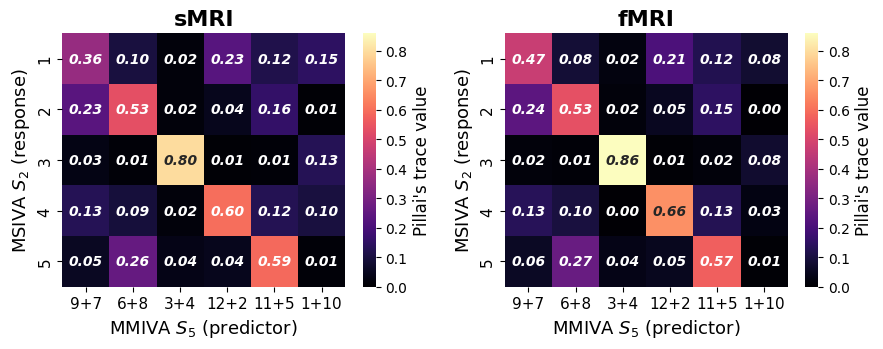

In [8]:
p_vals_logic = p_vals < 0.05/30
stats_list = ["Wilks' lambda", "Pillai's trace", "Hotelling-Lawley trace", "Roy's greatest root"]
modality_list = ["sMRI", "fMRI"]
xtick_list = ["9+7", "6+8", "3+4", "12+2", "11+5", "1+10"]

for j in [1]:
    stats = stats_list[j]
    plt.figure(figsize=(9,3.6))
    for i in range(2):
        plt.subplot(1,2,i+1)
        f = sns.heatmap(f_stats[j, i]/2, mask=p_vals_logic[j, i]==True, vmin=0, vmax=np.max([np.max(f_stats[j,0]),np.max(f_stats[j,1])])/2, cmap="magma", annot=True, fmt=".2f")
        sns.heatmap(f_stats[j, i]/2, mask=p_vals_logic[j, i]==False, 
                    annot_kws={"style": "oblique", "weight": "bold"}, annot=True, fmt=".2f",
                    vmin=0, vmax=np.max([np.max(f_stats[j,0]),np.max(f_stats[j,1])])/2, cmap="magma", cbar=False)
        cb = f.collections[0].colorbar
        cb.ax.tick_params(labelsize=10)
        cb.set_label(label=f"{stats} value", fontsize=12)
        plt.title(f"{modality_list[i]}", fontsize=16, fontweight="bold")
        plt.xlabel("MMIVA $S_5$ (predictor)", fontsize=13)
        plt.ylabel("MSIVA $S_2$ (response)", fontsize=13)
        plt.xticks(np.arange(0.5,6.5,1), xtick_list, fontsize=11)
        plt.yticks(np.arange(0.5,5.5,1), np.arange(1,6), fontsize=11)
    stats.replace("'", "")
    stats.replace(" ", "_")
    plt.tight_layout()
    plt.savefig(f"figures/multivariate_regression_value_{stats}_bold_UKB.pdf")